<a href="https://colab.research.google.com/github/yhail001/trash/blob/main/tensorflowcourse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
%matplotlib inline

import sklearn.metrics
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import io
import glob
import scipy.misc
import numpy as np
import pandas as pd
from six import BytesIO
from PIL import Image, ImageDraw, ImageFont
import shutil
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras import layers
from tensorflow.keras import Model
import matplotlib
from tensorflow.keras.optimizers import RMSprop
import os
import zipfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.image as mpimg
from matplotlib.ticker import FormatStrFormatter
from tensorflow.keras.utils import plot_model


LEARNING_RATE = 0.0001
repo_url = 'https://github.com/adleberg/medical-ai'
IMAGE_HEIGHT, IMAGE_WIDTH = 299, 299

def load_image_into_numpy_array(image):
    image = image.convert('RGB')
    (im_width, im_height) = image.size
    return np.array(image.getdata()).reshape(
        (im_height, im_width, 3)).astype(np.uint8)

print("Welcome! Downloading some things... this will take a minute.")

%cd -q /content
repo_dir_path = os.path.abspath(os.path.join('.', os.path.basename(repo_url)))
!git clone {repo_url} --quiet
%cd -q {repo_dir_path}
!git pull -q

!apt-get install graphviz -y
!pip install pydot

print("Great! You clicked on it correctly. Now let's get started.")

Welcome! Downloading some things... this will take a minute.
fatal: destination path 'medical-ai' already exists and is not an empty directory.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Great! You clicked on it correctly. Now let's get started.


In [51]:
finding = "cardiomegaly"
finding = finding.capitalize()

In [52]:
df = pd.read_csv("/content/medical-ai/labels.csv")
df.head()

,filename,height,width,label,xmin,ymin,xmax,ymax,view
0,00013118_008.jpg,2992,2991,Atelectasis,225.0,547.0,311.0,626.0,PA
1,00014716_007.jpg,3056,2544,Atelectasis,686.0,131.0,871.0,444.0,AP
2,00029817_009.jpg,3056,2544,Atelectasis,221.0,317.0,376.0,533.0,AP
3,00014687_001.jpg,2500,2048,Atelectasis,726.0,494.0,867.0,549.0,AP
4,00017877_001.jpg,2500,2048,Atelectasis,660.0,569.0,860.0,647.0,AP


In [53]:
positives = df.loc[df["label"] == finding]
negatives = df.loc[df["label"] == "No Finding"]
n = len(positives)
print(n)

146


In [54]:
TRAIN_RATIO = 0.8
TEST_RATIO = 0.2
TRAIN_N = int(n*TRAIN_RATIO)
TEST_N = int(n*TEST_RATIO)
print(TRAIN_N, TEST_N)

116 29


In [55]:
train_labels = pd.concat([positives[:TRAIN_N], negatives[:TRAIN_N]])
test_labels = pd.concat([positives[TRAIN_N:], negatives[TRAIN_N:n]])

In [56]:
#preparing data

In [57]:
rootdir = "/content/medical-ai/images/"
os.makedirs(rootdir+finding+"/test/positive", exist_ok=True)
os.makedirs(rootdir+finding+"/test/negative", exist_ok=True)
os.makedirs(rootdir+finding+"/train/positive", exist_ok=True)
os.makedirs(rootdir+finding+"/train/negative", exist_ok=True)

In [62]:
for idx, image in positives[:TRAIN_N].iterrows():
  source = os.path.join(rootdir, image["filename"])
  dst = os.path.join(rootdir, finding, "train", "positive", image["filename"])
  shutil.copy(source, dst)


for idx, image in positives[TRAIN_N:n].iterrows():
  source = os.path.join(rootdir, image["filename"])
  dst = os.path.join(rootdir, finding, "test", "positive", image["filename"])
  shutil.copy(source, dst)

for idx, image in negatives[:TRAIN_N].iterrows():
  source = os.path.join(rootdir, image["filename"])
  dst = os.path.join(rootdir, finding, "train", "negative", image["filename"])
  shutil.copy(source, dst)


for idx, image in negatives[TRAIN_N:n].iterrows():
  source = os.path.join(rootdir, image["filename"])
  dst = os.path.join(rootdir, finding, "test", "negative", image["filename"])
  shutil.copy(source, dst)

print("Done moving "+str(n*2)+" images to positive and negative folders.")

Done moving 292 images to positive and negative folders.


In [59]:
positive_imgs, negative_imgs = [], []
IMAGE_HEIGHT, IMAGE_WIDTH = 300, 300

for idx, row in positives[:6].iterrows():
  image_path = rootdir+row["filename"]
  image = Image.open(image_path).resize((IMAGE_HEIGHT, IMAGE_WIDTH))
  positive_imgs.append(load_image_into_numpy_array(image))

for idx, row in negatives[:6].iterrows():
  image_path = rootdir+row["filename"]
  image = Image.open(image_path).resize((IMAGE_HEIGHT, IMAGE_WIDTH))
  negative_imgs.append(load_image_into_numpy_array(image))

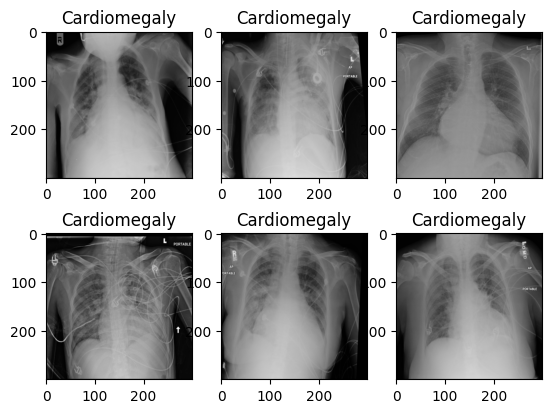

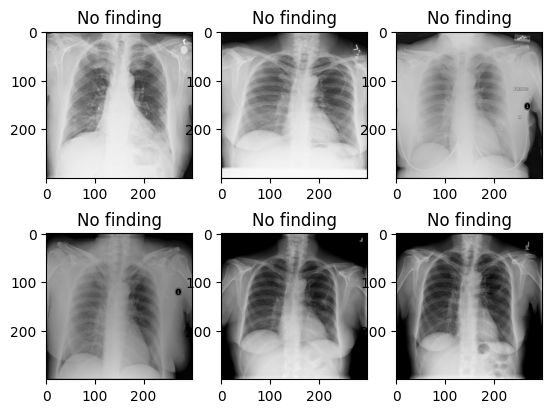

In [60]:
for idx, img in enumerate(positive_imgs[:6]):
  plt.subplot(2, 3, idx+1)
  plt.title(finding)
  plt.imshow(positive_imgs[idx])
plt.show()

for idx, img in enumerate(negative_imgs[:6]):
  plt.subplot(2, 3, idx+1)
  plt.title("No finding")
  plt.imshow(negative_imgs[idx])
plt.show()

In [63]:
pre_trained_model = EfficientNetB7(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), weights='imagenet', include_top=False)

for layer in pre_trained_model.layers:
  layer.trainable = False

x = layers.Flatten()(pre_trained_model.output)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(1, activation='sigmoid')(x)

model = Model(pre_trained_model.input, x)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])


In [ ]:
#define our example directories and files
base_dir = "/content/medical-ai/images"
train_dir = os.path.join(base_dir, finding, 'train')
test_dir = os.path.join(base_dir, finding, 'test')


train_pos_dir = os.path.join(train_dir, 'positive')
train_neg_dir = os.path.join(train_dir, 'negative')
test_pos_dir = os.path.join(test_dir, 'positive')
test_neg_dir = os.path.join(test_dir, 'negative')


In [ ]:
#data augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
)

val_datagen = ImageDataGenerator(rescale=1./255,)

In [64]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=1,
    class_mode='binary'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=1,
    class_mode='binary'
)

train_steps = len(os.listdir(train_pos_dir)) * 2
test_steps = len(os.listdir(test_pos_dir)) * 2

Found 232 images belonging to 2 classes.
Found 60 images belonging to 2 classes.


In [ ]:
#running the model > data and model have been set up

In [66]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=20,
    validation_data=test_generator,
    validation_steps=test_steps,
    verbose=2
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


232/232 - 127s - 547ms/step - acc: 0.5172 - loss: 118.6978 - val_acc: 0.5000 - val_loss: 14.4069
Epoch 2/20
232/232 - 17s - 73ms/step - acc: 0.4741 - loss: 35.8873 - val_acc: 0.5000 - val_loss: 16.5520
Epoch 3/20
232/232 - 17s - 74ms/step - acc: 0.5086 - loss: 3.6447 - val_acc: 0.5000 - val_loss: 0.6940
Epoch 4/20
232/232 - 17s - 74ms/step - acc: 0.4828 - loss: 0.7380 - val_acc: 0.5000 - val_loss: 0.6931
Epoch 5/20
232/232 - 17s - 75ms/step - acc: 0.4957 - loss: 0.6945 - val_acc: 0.5000 - val_loss: 0.6931
Epoch 6/20
232/232 - 20s - 86ms/step - acc: 0.4569 - loss: 0.9323 - val_acc: 0.5000 - val_loss: 0.6931
Epoch 7/20
232/232 - 21s - 92ms/step - acc: 0.5000 - loss: 1.0003 - val_acc: 0.5000 - val_loss: 0.6932
Epoch 8/20
232/232 - 38s - 165ms/step - acc: 0.5388 - loss: 0.6971 - val_acc: 0.5000 - val_loss: 0.6932
Epoch 9/20
232/232 - 18s - 79ms/step - acc: 0.4483 - loss: 0.6932 - val_acc: 0.5000 - val_loss: 0.6934
Epoch 10/20
232/232 - 18s - 79ms/step - acc: 0.4784 - loss: 0.8525 - val_acc

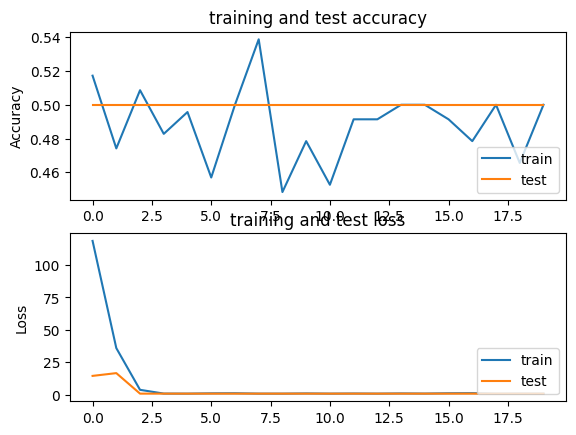

In [70]:
acc = history.history['acc']
val_acc = history.history['val_acc']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.subplot(2,1,1)
plt.plot(epochs, acc, label="train")
plt.plot(epochs, val_acc, label="test")
plt.ylabel("Accuracy")
plt.title("training and test accuracy")
plt.legend(loc="lower right")

plt.subplot(2,1,2)
plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="test")
plt.ylabel('Loss')
plt.title("training and test loss")
plt.legend(loc="lower right")